In [1]:
import refinitiv.data as rd
import pandas as pd
from datetime import date, timedelta, datetime
import numpy as np
import matplotlib.pyplot as plt

In [2]:
key = '033f10de0c08444c88216ceb12d424d809660a40'
rd.open_session(app_key=key)

<refinitiv.data.session.Definition object at 0x249d4f00a10 {name='workspace'}>

# Initial screener

Using the screen function of refinitiv to gather all active tickers in US

In [3]:
#Using a Refinitiv SCREEN() expression to retrieve the universe of active tickers in the US
screener = (
    'SCREEN('
      'U(IN(Equity(active,public,primary))/*UNV:Public*/), '
      # US‐listed
      'TR.ExchangeCountryCode = "US"'
    ')'
)

# the data i want to gather (will be useful to do further screening)
fields = [
    'TR.CommonName',
    'TR.CompanyMarketCap(Scale=0)',
    'TR.ExchangeName',
    'TR.TRBCEconomicSector',
    'TR.TRBCIndustryGroup',
    'TR.AssetCategory',
    'TR.FirstTradeDate'
]

screener_usa = rd.get_data(screener, fields)
screener_usa

c:\Users\Ramon\AppData\Local\Programs\Python\Python312\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\Ramon\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\dtypes\cast.py:1056:RuntimeWarning: invalid value encountered in cast
c:\Users\Ramon\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\dtypes\cast.py:1080:RuntimeWarning: invalid value encountered in cast


,Instrument,Company Common Name,Company Market Cap,Exchange Name,TRBC Economic Sector Name,TRBC Industry Group Name,Asset Category Description,First Trade Date
0,PLLVF.PK,Palladon Ventures Ltd,27.395506,USA Pink Sheets,Basic Materials,Metals & Mining,Ordinary Share,2001-10-26
1,DTRK.PK,DATATRAK International Inc,6570802.16,USA Pink Sheets,Technology,Software & IT Services,Ordinary Share,1996-06-11
2,MRCR.PK,Moro Corp,32248905.99,USA Pink Sheets,Basic Materials,Construction Materials,Ordinary Share,2000-08-15
3,HGYN.PK,Hong Yuan Holding Group,2836349.108,USA Pink Sheets,Industrials,Professional & Commercial Services,Ordinary Share,2005-11-04
4,FN.N,Fabrinet,16549663115.299999,New York Stock Exchange,Technology,Electronic Equipment & Parts,Ordinary Share,2010-06-25
...,...,...,...,...,...,...,...,...
13715,LPCVU.OQ,Launchpad Cadenza Acquisition Corp I,200000000.0,NASDAQ Stock Exchange Global Market,Financials,Investment Holding Companies,Unit,2025-12-18
13716,IGAC.OQ,Invest Green Acquisition Corp,234880800.0,NASDAQ Stock Exchange Global Market,Financials,Investment Holding Companies,Ordinary Share,2025-12-22
13717,SWDR.PK,Starwood Real Estate Income Trust Inc,<NA>,USA Pink Sheets,Real Estate,Residential & Commercial REITs,Ordinary Share,2025-12-22
13718,SCPQU.OQ,Social Commerce Partners Corp,103603500.0,NASDAQ Stock Exchange Global Market,Financials,Investment Holding Companies,Unit,2025-12-23


# Initial filters

Avoid companies from Financials', 'Utilities', 'Real Estate', 'Government Activity', 'Institutions, Associations & Organizations' economic sectors <br>
Exclude companies that trade in OTC Markets <br>
Only companies with more than 1 billion in market cap <br>
Only ordinary shares <br>
Only companies with more than 5 years of historical data

In [4]:
# Filters for the screener

# exclude financials, utilities, real estate, Government Activity and Institutions, Associations & Organizations (economic sectors)
filtered_usa = screener_usa[~screener_usa['TRBC Economic Sector Name'].isin(['Financials', 'Utilities', 'Real Estate', 'Government Activity', 
                                                                             'Institutions, Associations & Organizations'])] #keeping only those that aren't the ones in the list

# exclude companies that trade in otc markets
filtered_usa = filtered_usa[~screener_usa['Exchange Name'].isin(['USA Pink Sheets'])]

#include only companies with more than 1 billion in market cap
filtered_usa = filtered_usa[filtered_usa['Company Market Cap'] >= 1e9]

#include only ordinary shares
filtered_usa = filtered_usa[filtered_usa['Asset Category Description'] == 'Ordinary Share']

# number of years since first trade
filtered_usa['Years Since First Trade'] = (datetime.now() - filtered_usa['First Trade Date']).dt.days / 365.25

#include only companies with more than 5 years of historical data
filtered_usa = filtered_usa[filtered_usa['Years Since First Trade'] >= 5]

filtered_usa

C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\1975143228.py:8:UserWarning: Boolean Series key will be reindexed to match DataFrame index.


,Instrument,Company Common Name,Company Market Cap,Exchange Name,TRBC Economic Sector Name,TRBC Industry Group Name,Asset Category Description,First Trade Date,Years Since First Trade
4,FN.N,Fabrinet,16549663115.299999,New York Stock Exchange,Technology,Electronic Equipment & Parts,Ordinary Share,2010-06-25,15.518138
5,TGLS.N,Tecnoglass Inc,2400654941.3,New York Stock Exchange,Consumer Cyclicals,Homebuilding & Construction Supplies,Ordinary Share,2012-05-10,13.642710
7,NEGG.OQ,Newegg Commerce Inc,1102836848.0,NASDAQ Stock Exchange Capital Market,Technology,Software & IT Services,Ordinary Share,2010-04-22,15.693361
8,SPSC.OQ,SPS Commerce Inc,3424362826.14,Nasdaq Stock Exchange Global Select Market,Technology,Software & IT Services,Ordinary Share,2010-04-22,15.693361
45,TSLA.OQ,Tesla Inc,1511352004059.810059,Nasdaq Stock Exchange Global Select Market,Consumer Cyclicals,Automobiles & Auto Parts,Ordinary Share,2010-06-29,15.507187
...,...,...,...,...,...,...,...,...,...
12339,ST.N,Sensata Technologies Holding PLC,4811768617.05,New York Stock Exchange,Technology,Electronic Equipment & Parts,Ordinary Share,2010-03-11,15.808350
12352,MXL.OQ,Maxlinear Inc,1546499161.8,Nasdaq Stock Exchange Global Select Market,Technology,Semiconductors & Semiconductor Equipment,Ordinary Share,2010-03-24,15.772758
12361,STNG.N,Scorpio Tankers Inc,2624373453.0,New York Stock Exchange,Energy,Oil & Gas Related Equipment and Services,Ordinary Share,2010-03-31,15.753593
12363,SSNC.OQ,SS&C Technologies Holdings Inc,21596425165.5,Nasdaq Stock Exchange Global Select Market,Technology,Software & IT Services,Ordinary Share,2010-03-31,15.753593


In [5]:
end_date = date.today()
start_date = end_date.replace(year=end_date.year - 5)

print(start_date)
print(end_date)

2020-12-31
2025-12-31


# Functions to gather data from Refinitiv

I coded functions to gather financial data of last 5 years for building the quality factor; last price and TTM financial data for value factor; last 12 months of returns for momentum factor. <br>

All the data is retrieved initially and stored in dictionaries where the key is the ticker and the value is a DF with the data

In [6]:
fields = [
    # Income Statement
    'TR.F.TotRevenue', 'TR.F.COGSTot', 'TR.F.GrossProfIndPropTot', 'TR.F.IncBefTax', 'TR.F.IncTax', 'TR.F.NetIncAfterTax', 'TR.F.IncAvailToComShr', 
    'TR.F.EBIT', 'TR.F.EBITDA',
    # Balance Sheet
    'TR.F.CashCashEquivTot', 'TR.F.TotCurrAssets', 'TR.F.TotAssets', 'TR.F.STDebtCurrPortOfLTDebt', 'TR.F.TotCurrLiab', 'TR.F.DebtLTTot',
    'TR.F.ComEqParentShHold','TR.F.ComShrOutsTot', 'TR.F.NetDebt',
    # Cash Flow
    'TR.F.NetCashFlowOp'
]

def get_raw_data(ticker, start_date=start_date, end_date=end_date):
    df = rd.get_history(
        universe=ticker,
        fields=fields,
        parameters={'Frq': 'FY', 'Period': 'FY0'},
        start=start_date,
        end=end_date,
    )
    df = df.apply(pd.to_numeric, errors='coerce')
    return df.fillna(0)

In [7]:
fields_ttm = [
    #EV
    'TR.F.ComShrOutsTot', 'TR.F.DebtLTTot', 'TR.F.STDebtCurrPortOfLTDebt', 'TR.F.PrefShHoldEq', 'TR.F.MinIntr', 'TR.F.CashCashEquivTot',
    #CFO and FCF
    'TR.F.NetCashFlowOp', 'TR.F.LeveredFOCF',
    #EBIT, revenue and eps
    'TR.F.EBIT', 'TR.F.TotRevenue', 'TR.F.EPSBasicExclExordItemsComTot'
    ]

def get_raw_data_ttm(ticker, end_date=end_date):
    df = rd.get_history(
        universe=ticker,
        fields=fields_ttm,
        parameters={'Frq': 'FQ', 'Period': 'FQ0'},
        start= end_date - timedelta(days=365),
        end=end_date,
    )
    df = df.apply(pd.to_numeric, errors='coerce')
    return df.fillna(0)

def get_last_price(ticker, end_date=end_date):
    df = rd.get_history(
    universe = ticker,
    fields = ['TR.PriceClose'],
    interval= '1D',
    start = end_date - timedelta(days=1),
    end = end_date)

    return df.fillna(0)

def get_monthly_return(ticker, end_date=end_date):
    df = rd.get_history(
    universe = ticker,
    fields = ['TR.TotalReturn'],
    interval= '1M',
    start = end_date - timedelta(days=335),
    end = end_date + timedelta(days=1))

    return df.fillna(0)

In [8]:
#store fundamental data for each ticker in a dictionary
#the keys for the dictionary are the tickers and the values the dfs with fundamental data
tickers_data = {}
error_tickers = []

for ticker in filtered_usa['Instrument']:
    try:
        tickers_data[ticker] = get_raw_data(ticker, start_date, end_date) #get raw data for each ticker
    except Exception as e:
        error_tickers.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

c:\Users\Ramon\AppData\Local\Programs\Python\Python312\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\Ramon\AppData\Local\Programs\Python\Python312\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\Ramon\AppData\Local\Programs\Python\Python312\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To re

In [9]:
#store fundamental data for each ticker in a dictionary
#the keys for the dictionary are the tickers and the values the dfs with fundamental data
tickers_data_ttm = {}
error_tickers_ttm = []

for ticker in filtered_usa['Instrument']:
    try:
        tickers_data_ttm[ticker] = get_raw_data_ttm(ticker, end_date) #get raw data for each ticker
    except Exception as e:
        error_tickers_ttm.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

c:\Users\Ramon\AppData\Local\Programs\Python\Python312\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\Ramon\AppData\Local\Programs\Python\Python312\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\Ramon\AppData\Local\Programs\Python\Python312\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To re

In [10]:
#store daily prices for each ticker in a dictionary
tickers_last_price = {}
error_tickers_prices = []

for ticker in filtered_usa['Instrument']:
    try:
        tickers_last_price[ticker] = get_last_price(ticker, end_date)
    except Exception as e:
        error_tickers_prices.append(ticker)
        print(f'Error fetching {ticker}: {e}')
        continue

In [11]:
#store daily prices for each ticker in a dictionary
tickers_monthly_return = {}
error_tickers_montly_return = []

for ticker in filtered_usa['Instrument']:
    try:
        tickers_monthly_return[ticker] = get_monthly_return(ticker, end_date)
    except Exception as e:
        error_tickers_montly_return.append(ticker)
        print(f'Error fetching {ticker}: {e}')
        continue

In [12]:
print(error_tickers)
print(error_tickers_ttm)
print(error_tickers_prices)
print(error_tickers_montly_return)

[]
[]
[]
[]


In [13]:
tickers_data['UTHR.OQ']

UTHR.OQ,Revenue from Business Activities - Total,Cost of Revenues - Total,Gross Profit - Industrials/Property - Total,Income before Taxes,Income Taxes,Net Income after Tax,Income Available to Common Shares,Earnings before Interest & Taxes (EBIT),Earnings before Interest Taxes Depreciation & Amortization,Cash & Cash Equivalents - Total,Total Current Assets,Total Assets,Short-Term Debt & Current Portion of Long-Term Debt,Total Current Liabilities,Debt - Long-Term - Total,Common Equity Attributable to Parent Shareholders,Common Shares - Outstanding - Total,Net Debt,Net Cash Flow from Operating Activities
Date,,,,,,,,,,,,,,,,,,,
2020-12-31,1483300000,108100000,1375200000,638900000,124100000,514800000,514800000,593600000,643500000,738700000,2167200000,4615000000,0,323300000,800000000,3395200000,44507098,-1035000000,755700000
2021-12-31,1685500000,122500000,1563000000,593900000,118100000,475800000,475800000,688500000,738400000,894800000,2323600000,5169100000,0,305400000,800000000,3958900000,45107805,-1130700000,598200000
2022-12-31,1936300000,151600000,1784700000,950600000,223300000,727300000,727300000,990900000,1042200000,961200000,3380300000,6044500000,0,343200000,800000000,4796700000,46032064,-2038700000,802500000
2023-12-31,2327500000,257500000,2070000000,1274300000,289500000,984800000,984800000,1188500000,1241700000,1207700000,3551000000,7167000000,400000000,804400000,300000000,5984800000,47040545,-2294100000,978000000
2024-12-31,2877400000,309700000,2567700000,1539000000,343900000,1195100000,1195100000,1448100000,1520600000,1697200000,3873900000,7364000000,300000000,738100000,0,6444000000,44831306,-2967000000,1327100000


In [14]:
tickers_data_ttm['UTHR.OQ']

UTHR.OQ,Common Shares - Outstanding - Total,Debt - Long-Term - Total,Short-Term Debt & Current Portion of Long-Term Debt,Preferred Shareholders Equity,Minority Interest,Cash & Cash Equivalents - Total,Net Cash Flow from Operating Activities,Free Cash Flow,Earnings before Interest & Taxes (EBIT),Revenue from Business Activities - Total,"EPS - Basic - excl Extraordinary Items, Common - Total"
Date,,,,,,,,,,,
2024-12-31,44831306,0,300000000,0,0.0,1697200000,341200000,254500000,363700000,735900000,6.71047
2025-03-31,45074551,0,200000000,0,0.0,1899900000,461200000,386300000,382800000,794400000,7.17595
2025-06-30,45215262,0,0,0,0.0,1593100000,191700000,129500000,386200000,798600000,6.86253
2025-09-30,42902818,0,0,0,0.0,1340100000,562100000,346100000,389300000,799500000,7.73288


In [15]:
tickers_last_price['UTHR.OQ']

UTHR.OQ,Price Close
Date,
2025-12-30,496.19


In [20]:
tickers_monthly_return['UTHR.OQ']

UTHR.OQ,Total Return
Date,
2025-01-31,-0.473302
2025-02-28,-8.861805
2025-03-31,-3.680675
2025-04-30,-1.680345
2025-05-30,5.199776
2025-06-30,-9.879254
2025-07-31,-4.402297
2025-08-29,10.942847
2025-09-30,37.554141


# Initial quality filter

Research had show great returns when value factor is combined with Piotroski Fs-Score, in this case I'm not using it to build the quality factor but instead as an initial filter to avoid "junk". I'll only keep stocks with more than 3 of Fs-Score

In [21]:
# Initial filter to avoid junk

def fs_score(ticker): 
    df = tickers_data[ticker]
    # Require at least 2 years of fundamental data
    if len(df) < 2:
        print(f"{ticker}: not enough data for F-score")
        return None
    
    net_income, assets, lt_debt, current_assets = df['Income Available to Common Shares'], df['Total Assets'], df['Debt - Long-Term - Total'], df['Total Current Assets']
    current_liabilities, shares, revenue, gross = df['Total Current Liabilities'], df['Common Shares - Outstanding - Total'], df['Revenue from Business Activities - Total'], df['Gross Profit - Industrials/Property - Total']
    cfo = df['Net Cash Flow from Operating Activities']
    
    roa = net_income / assets
    leverage = lt_debt / assets
    current = current_assets / current_liabilities
    gross_margin = gross / revenue
    asset_turnover = revenue / assets
    
    score = 0
    try:
        # current profitability
        score += int(roa.iloc[-1] > 0) # positive roa
        score += int(roa.iloc[-1] > roa.iloc[-2]) #roa improving
        score += int(cfo.iloc[-1] > 0) #positive cfo
        score += int((cfo.iloc[-1] - net_income.iloc[-1]) > 0) # accrual quality
        # stability
        score += int(leverage.iloc[-1] < leverage.iloc[-2]) #lt debt to assets decreasing 
        score += int(current.iloc[-1] > current.iloc[-2]) #current ratio improving
        score += int(shares.iloc[-1] <= shares.iloc[-2]) #no new shares
        # operational efficiency
        score += int(gross_margin.iloc[-1] > gross_margin.iloc[-2]) #gross margin improving
        score += int(asset_turnover.iloc[-1] > asset_turnover.iloc[-2]) #asset turnover improving
        
    except Exception as e:
        print(f'F-score error: {e} with {ticker}')
        return None
    
    return score

In [22]:
# creating a df with all the tickers except the ones in error_tickers
Fscore_df = filtered_usa.loc[~filtered_usa['Instrument'].isin(error_tickers),['Instrument', 'TRBC Economic Sector Name', 'TRBC Industry Group Name']]

# applying fs_score function to each ticker
Fscore_df['FS_Score'] = Fscore_df['Instrument'].apply(fs_score)
Fscore_df = Fscore_df.dropna(subset = ['FS_Score'])

# Sorting them by fscore
Fscore_df = Fscore_df.sort_values(by = 'FS_Score', ascending = False)
Fscore_df

,Instrument,TRBC Economic Sector Name,TRBC Industry Group Name,FS_Score
6820,ICLR.OQ,Healthcare,Biotechnology & Medical Research,9
10031,MOD.N,Consumer Cyclicals,Automobiles & Auto Parts,9
6803,HALO.OQ,Healthcare,Pharmaceuticals,9
6833,CMCSA.OQ,Technology,Telecommunications Services,9
9573,CCK.N,Basic Materials,Containers & Packaging,9
...,...,...,...,...
5741,BEAM.OQ,Healthcare,Biotechnology & Medical Research,1
9812,GEF.N,Basic Materials,Containers & Packaging,1
6155,HYMC.OQ,Basic Materials,Metals & Mining,1
6226,DNLI.OQ,Healthcare,Biotechnology & Medical Research,1


C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\860687396.py:13:UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


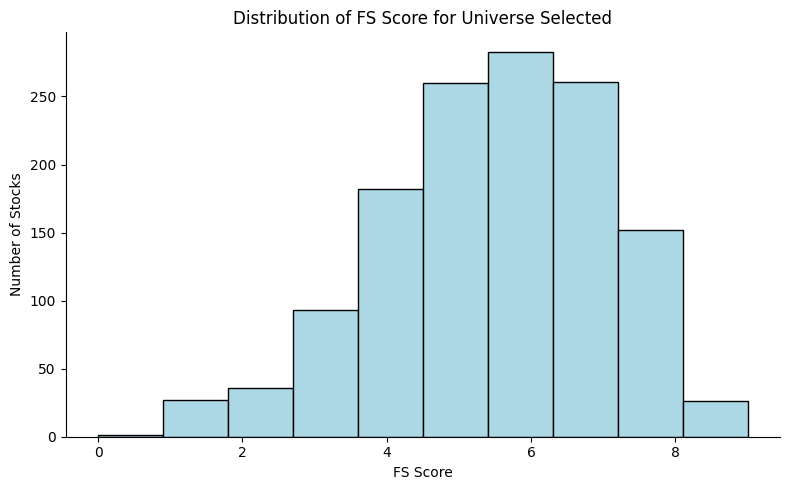

In [23]:
# Distribution of Fs_score for the universe selected

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(Fscore_df['FS_Score'], bins=10, color='lightblue', edgecolor='black')
ax.set_title('Distribution of FS Score for Universe Selected')
ax.set_ylabel('Number of Stocks')
ax.set_xlabel('FS Score')

ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.show()

In [24]:
# Avoid junk stocks
# Keep only stocks with fscore above 3

final_stocks = Fscore_df.loc[Fscore_df['FS_Score'] > 3]
final_stocks

,Instrument,TRBC Economic Sector Name,TRBC Industry Group Name,FS_Score
6820,ICLR.OQ,Healthcare,Biotechnology & Medical Research,9
10031,MOD.N,Consumer Cyclicals,Automobiles & Auto Parts,9
6803,HALO.OQ,Healthcare,Pharmaceuticals,9
6833,CMCSA.OQ,Technology,Telecommunications Services,9
9573,CCK.N,Basic Materials,Containers & Packaging,9
...,...,...,...,...
9887,HUN.N,Basic Materials,Chemicals,4
1161,W.N,Consumer Cyclicals,Diversified Retail,4
7055,IOSP.OQ,Basic Materials,Chemicals,4
6973,MASI.OQ,Healthcare,Healthcare Equipment & Supplies,4


In [25]:
final_stocks['TRBC Economic Sector Name'].value_counts()

TRBC Economic Sector Name
Technology                         268
Industrials                        245
Consumer Cyclicals                 219
Healthcare                         184
Consumer Non-Cyclicals              83
Basic Materials                     80
Energy                              76
Academic & Educational Services      9
Name: count, dtype: Int64

# Quality factor

In [26]:
#profitability
def roa(ticker):
    try:
        df = tickers_data[ticker]
        ni, assets = df['Income Available to Common Shares'], df['Total Assets']
        roa = ni / assets
        return roa.mean(), roa.std()
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

def roic(ticker, tax_cap=.35):
    try:
        df = tickers_data[ticker]  
        ebit, ebt, i_taxes = df['Earnings before Interest & Taxes (EBIT)'], df['Income before Taxes'], df['Income Taxes']
        st_debt, lt_debt = df['Short-Term Debt & Current Portion of Long-Term Debt'], df['Debt - Long-Term - Total']
        equity, cash = df["Common Equity Attributable to Parent Shareholders"], df['Cash & Cash Equivalents - Total']
        
        eff_tax_rate = (i_taxes / ebt).clip(0, tax_cap) # in case is negative or really high
        total_debt = st_debt + lt_debt
        nopat = ebit * (1 - eff_tax_rate)
        i_capital = equity + total_debt - cash
        roic = nopat / i_capital
        return roic.mean(), roic.std()
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def gp_assets(ticker):
    try:
        df = tickers_data[ticker]
        gross, assets = df['Gross Profit - Industrials/Property - Total'], df['Total Assets']
        gp_assets = gross / assets
        return gp_assets.mean(), gp_assets.std()

    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
# earnings quality (accruals)

def acc_assets(ticker):
    try:
        df = tickers_data[ticker]
        cfo, ni, assets = df['Net Cash Flow from Operating Activities'], df['Income Available to Common Shares'], df['Total Assets']
        acc = ni - cfo
        last_acc = acc.iloc[-1]
        if assets.iloc[-1] == 0 or assets.iloc[-2] == 0:
            return np.nan #return na if assets are 0 to avoid inf
        last_avg_assets = (assets[-1] + assets[-2]) / 2
        acc_a = last_acc / last_avg_assets
        return acc_a
      
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None


# leverage

def ndebt_ebitda(ticker):
    #if one negative ebitda i will override the ndebt_ebitda z score with the 20th percentile
    #if two negative ebitda i will override the ndebt_ebitda z score with the 5th percentile
    #if three negative i will just invalidate and drop stock
    try:
        df = tickers_data[ticker]
        n_debt, ebitda = df['Net Debt'], df['Earnings before Interest Taxes Depreciation & Amortization']
        neg_count = (ebitda.tail(3) <= 0).sum()
        if neg_count == 1:
            return None, 'P'
        elif neg_count == 2:
            return None, 'HP'
        elif neg_count == 3:
            return None, 'INV'
        
        nd_clip = n_debt.tail(3).clip(lower=0) #make negative net debt into 0
        nd_ebitda = nd_clip / ebitda.tail(3)
        return nd_ebitda.tail(3).median(), 'VAL'

    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

def debt_assets(ticker):
    try:
        df = tickers_data[ticker]
        st_debt, lt_debt, assets = df['Short-Term Debt & Current Portion of Long-Term Debt'], df['Debt - Long-Term - Total'], df['Total Assets']
        tot_debt = st_debt + lt_debt
        d_a = tot_debt / assets
        return d_a.tail(3).median()

    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

In [27]:
print(roa('META.OQ'))
print(roic('META.OQ'))
print(gp_assets('META.OQ'))
print(acc_assets('META.OQ'))
print(ndebt_ebitda('META.OQ'))
print(debt_assets('META.OQ'))


(0.18824291882528965, 0.04520787866833331)
(0.306659577433299, 0.06286436496761039)
(0.49395691953051724, 0.050952517772568325)
-0.11457115906003239
(0.0, 'VAL')
0.08307094672571999


C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\1871974361.py:52:FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [28]:
# creating a df with all the tickers except the ones in error_tickers
quality_metrics_df = final_stocks[['Instrument', 'TRBC Economic Sector Name']].copy()

# applying fs_score function to each ticker
quality_metrics_df[['roa', 'roa_std']] = quality_metrics_df['Instrument'].apply(roa).apply(pd.Series)
quality_metrics_df[['roic', 'roic_std']] = quality_metrics_df['Instrument'].apply(roic).apply(pd.Series)
quality_metrics_df[['gp_assets', 'gp_assets_std']] = quality_metrics_df['Instrument'].apply(gp_assets).apply(pd.Series)
quality_metrics_df['acc_assets'] = quality_metrics_df['Instrument'].apply(acc_assets)
quality_metrics_df[['ndebt_ebitda', 'valid']]  = quality_metrics_df['Instrument'].apply(ndebt_ebitda).apply(pd.Series) #fun return 2 values, df will have 2 columns
quality_metrics_df['debt_assets'] = quality_metrics_df['Instrument'].apply(debt_assets)
quality_metrics_df

C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\1871974361.py:52:FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


,Instrument,TRBC Economic Sector Name,roa,roa_std,roic,roic_std,gp_assets,gp_assets_std,acc_assets,ndebt_ebitda,valid,debt_assets
6820,ICLR.OQ,Healthcare,0.043576,0.032798,0.106419,0.090073,0.121042,0.05735,-0.029242,2.081020,VAL,0.222226
10031,MOD.N,Consumer Cyclicals,0.035124,0.112924,0.154229,0.037178,0.262969,0.047885,-0.015547,1.205777,VAL,0.225238
6803,HALO.OQ,Healthcare,0.214933,0.09524,0.249964,0.078989,0.33608,0.051393,-0.018423,2.753595,VAL,0.817861
6833,CMCSA.OQ,Technology,0.045918,0.016453,0.089368,0.015789,0.249555,0.027434,-0.043245,2.414705,VAL,0.372235
9573,CCK.N,Basic Materials,0.021133,0.035429,0.122182,0.02538,0.129057,0.020188,-0.053182,3.278427,VAL,0.488357
...,...,...,...,...,...,...,...,...,...,...,...,...
9887,HUN.N,Basic Materials,0.054653,0.06237,0.065958,0.054841,0.145942,0.03043,-0.062944,3.021053,VAL,0.232892
1161,W.N,Consumer Cyclicals,-0.142929,0.16117,0.777007,1.254531,0.959024,0.086233,-0.233377,NaN,HP,0.901417
7055,IOSP.OQ,Basic Materials,0.052946,0.031041,0.12901,0.042244,0.309419,0.049317,-0.086517,0.000000,VAL,0.000000
6973,MASI.OQ,Healthcare,0.043475,0.101546,0.153907,0.130728,0.380903,0.050683,-0.176913,2.829398,VAL,0.297879


In [29]:
quality_metrics_df.isna().sum()

Instrument                     0
TRBC Economic Sector Name      0
roa                            5
roa_std                       11
roic                           5
roic_std                       9
gp_assets                      5
gp_assets_std                 11
acc_assets                     1
ndebt_ebitda                 144
valid                          0
debt_assets                    0
dtype: int64

In [30]:
# drop the companies with 3 last years of consecutive negative ebitda
quality_metrics_df = quality_metrics_df[quality_metrics_df['valid'] != 'INV']
quality_metrics_df

,Instrument,TRBC Economic Sector Name,roa,roa_std,roic,roic_std,gp_assets,gp_assets_std,acc_assets,ndebt_ebitda,valid,debt_assets
6820,ICLR.OQ,Healthcare,0.043576,0.032798,0.106419,0.090073,0.121042,0.05735,-0.029242,2.081020,VAL,0.222226
10031,MOD.N,Consumer Cyclicals,0.035124,0.112924,0.154229,0.037178,0.262969,0.047885,-0.015547,1.205777,VAL,0.225238
6803,HALO.OQ,Healthcare,0.214933,0.09524,0.249964,0.078989,0.33608,0.051393,-0.018423,2.753595,VAL,0.817861
6833,CMCSA.OQ,Technology,0.045918,0.016453,0.089368,0.015789,0.249555,0.027434,-0.043245,2.414705,VAL,0.372235
9573,CCK.N,Basic Materials,0.021133,0.035429,0.122182,0.02538,0.129057,0.020188,-0.053182,3.278427,VAL,0.488357
...,...,...,...,...,...,...,...,...,...,...,...,...
9887,HUN.N,Basic Materials,0.054653,0.06237,0.065958,0.054841,0.145942,0.03043,-0.062944,3.021053,VAL,0.232892
1161,W.N,Consumer Cyclicals,-0.142929,0.16117,0.777007,1.254531,0.959024,0.086233,-0.233377,NaN,HP,0.901417
7055,IOSP.OQ,Basic Materials,0.052946,0.031041,0.12901,0.042244,0.309419,0.049317,-0.086517,0.000000,VAL,0.000000
6973,MASI.OQ,Healthcare,0.043475,0.101546,0.153907,0.130728,0.380903,0.050683,-0.176913,2.829398,VAL,0.297879


In [31]:
#drop na values except in ndebt_ebitda
quality_metrics_df = quality_metrics_df.dropna(subset=['roa', 'roa_std', 'gp_assets', 'gp_assets_std', 'roic', 'roic_std', 'acc_assets'])

In [32]:
quality_metrics_df.isna().sum()

Instrument                    0
TRBC Economic Sector Name     0
roa                           0
roa_std                       0
roic                          0
roic_std                      0
gp_assets                     0
gp_assets_std                 0
acc_assets                    0
ndebt_ebitda                 77
valid                         0
debt_assets                   0
dtype: int64

In [48]:
#NO SECTOR NEUTRALIZE AND PERCENTILES
quality_score_df = quality_metrics_df.copy()

#winsorize
roa_clip = quality_score_df['roa'].clip(lower=quality_score_df['roa'].quantile(.025),
                                     upper=quality_score_df['roa'].quantile(.975))

roa_std_clip = quality_score_df['roa_std'].clip(lower=quality_score_df['roa_std'].quantile(.025),
                                            upper=quality_score_df['roa_std'].quantile(.975))

roic_clip = quality_score_df['roic'].clip(lower=quality_score_df['roic'].quantile(.025),
                                        upper=quality_score_df['roic'].quantile(.975))
    
roic_std_clip = quality_score_df['roic_std'].clip(lower=quality_score_df['roic_std'].quantile(.025),
                                                upper=quality_score_df['roic_std'].quantile(.975))
    
gp_assets_clip = quality_score_df['gp_assets'].clip(lower=quality_score_df['gp_assets'].quantile(.025),
                                                                   upper=quality_score_df['gp_assets'].quantile(.975))

gp_assets_std_clip = quality_score_df['gp_assets_std'].clip(lower=quality_score_df['gp_assets_std'].quantile(.025),
                                                                           upper=quality_score_df['gp_assets_std'].quantile(.975))
    
acc_clip = quality_score_df['acc_assets'].clip(lower=quality_score_df['acc_assets'].quantile(.025),
                                                              upper=quality_score_df['acc_assets'].quantile(.975))
    
ndebt_ebitda_clip = quality_score_df['ndebt_ebitda'].clip(lower=quality_score_df['ndebt_ebitda'].quantile(.025),
                                                                         upper=quality_score_df['ndebt_ebitda'].quantile(.975))
    
debt_assets_clip = quality_score_df['debt_assets'].clip(lower=quality_score_df['debt_assets'].quantile(.025),
                                                                       upper=quality_score_df['debt_assets'].quantile(.975))

#for net debt to ebitda, transform the P, HP into 80th and 95th percentile
#higher net debt to ebitda is worse, so to penalize ill add the score of the 80th and 95th percentile
q80 = ndebt_ebitda_clip.quantile(.8)
q95 = ndebt_ebitda_clip.quantile(.95)

mask_p = quality_score_df['valid'] == 'P'
mask_hp = quality_score_df['valid'] == 'HP'
ndebt_ebitda_clip = ndebt_ebitda_clip.copy()
ndebt_ebitda_clip.loc[mask_p] = q80
ndebt_ebitda_clip.loc[mask_hp] = q95

# calculating percentiles
quality_score_df['roa_p'] = roa_clip.rank(pct=True) * 100
quality_score_df['roa_std_p'] = roa_std_clip.rank(pct=True) * 100
quality_score_df['roic_p'] = roic_clip.rank(pct=True) * 100
quality_score_df['roic_std_p'] = roic_std_clip.rank(pct=True) * 100
quality_score_df['gp_assets_p'] = gp_assets_clip.rank(pct=True) * 100
quality_score_df['gp_assets_std_p'] = gp_assets_std_clip.rank(pct=True) * 100
quality_score_df['acc_assets_p'] = acc_clip.rank(pct=True) * 100
quality_score_df['ndebt_ebitda_p'] = ndebt_ebitda_clip.rank(pct=True) * 100
quality_score_df['debt_assets_p'] = debt_assets_clip.rank(pct=True) * 100

# Final quality score
lam = .2 # how much do i want to penalize volatility
quality_score_df['profitability_score'] = (.2 * (quality_score_df['roa_p'] - lam * quality_score_df['roa_std_p']) +
                                        .2 * (quality_score_df['roic_p'] - lam * quality_score_df['roic_std_p']) + 
                                        .4 * (quality_score_df['gp_assets_p'] - lam * quality_score_df['gp_assets_std_p']))
quality_score_df['accrual_score'] = -(quality_score_df['acc_assets_p']) # negative because higher accruals are worse
quality_score_df['leverage_score'] = -(.75 * quality_score_df['ndebt_ebitda_p'] + 
                                    .25 * quality_score_df['debt_assets_p']) #negative because higher leverage is worse
quality_score_df['quality_score'] = (.5 * quality_score_df['profitability_score'] + 
                                  .3 * quality_score_df['accrual_score'] + 
                                  .20 * quality_score_df['leverage_score'])

# Creating a rank column and sorting them by rank
quality_score_df['quality_p'] = quality_score_df['quality_score'].rank(pct=True) * 100
quality_score_df['quality_rank'] = quality_score_df['quality_score'].rank(ascending = False)
quality_score_df = quality_score_df.sort_values(by = 'quality_score', ascending = False)

quality_score_df.head(20)

,Instrument,TRBC Economic Sector Name,roa,roa_std,roic,roic_std,gp_assets,gp_assets_std,acc_assets,ndebt_ebitda,...,gp_assets_std_p,acc_assets_p,ndebt_ebitda_p,debt_assets_p,profitability_score,accrual_score,leverage_score,quality_score,quality_p,quality_rank
6859,MANH.OQ,Technology,0.233756,0.041312,24.071044,40.190121,0.701283,0.038726,-0.107120,0.000000,...,49.816176,12.500000,11.580882,3.446691,67.450368,-12.500000,-9.547335,28.065717,100.000000,1.0
5341,SGHC.N,Consumer Cyclicals,0.169614,0.120939,0.530057,0.313248,1.55212,0.102348,-0.178620,0.000000,...,87.683824,3.952206,11.580882,13.786765,62.963235,-3.952206,-12.132353,27.869485,99.908088,2.0
6278,CARG.OQ,Technology,0.084507,0.09167,0.347455,0.182158,0.793684,0.145009,-0.269030,0.000000,...,94.025735,1.332721,11.580882,3.446691,57.606618,-1.332721,-9.547335,26.494026,99.816176,3.0
6738,CPRX.OQ,Healthcare,0.224284,0.096247,8.600676,17.487955,0.525877,0.084003,-0.114896,0.000000,...,80.974265,10.386029,11.580882,3.446691,61.064338,-10.386029,-9.547335,25.506893,99.724265,4.0
374,META.OQ,Technology,0.188243,0.045208,0.30666,0.062864,0.493957,0.050953,-0.114571,0.000000,...,63.419118,10.477941,11.580882,19.025735,61.533088,-10.477941,-13.442096,24.934743,99.632353,5.0
6939,ODFL.OQ,Industrials,0.21879,0.046368,0.30372,0.059047,0.901623,0.103732,-0.086009,0.000000,...,87.959559,19.025735,11.580882,12.408088,64.909926,-19.025735,-11.787684,24.389706,99.540441,6.0
6641,ADBE.OQ,Technology,0.192004,0.028034,0.433001,0.106883,0.595154,0.079461,-0.097144,0.000000,...,79.963235,14.889706,11.580882,34.099265,63.503676,-14.889706,-17.210478,23.842831,99.448529,7.0
986,ATEN.N,Technology,0.129625,0.067259,0.355209,0.104099,0.543417,0.057117,-0.098106,0.000000,...,67.738971,14.522059,11.580882,3.446691,60.014706,-14.522059,-9.547335,23.741268,99.356618,8.0
9896,IDT.N,Technology,0.112103,0.050779,0.807425,0.211935,0.651336,0.072868,-0.086657,0.000000,...,77.573529,18.474265,11.580882,3.446691,61.865809,-18.474265,-9.547335,23.481158,99.264706,9.0
7387,TXRH.OQ,Consumer Cyclicals,0.092591,0.04648,0.268354,0.138944,0.920808,0.171762,-0.106961,0.000000,...,96.875000,12.683824,11.580882,9.558824,58.044118,-12.683824,-11.075368,23.001838,99.172794,10.0


In [49]:
# To sector neutralize the ratios i have to groupby each sector
sectors = list(quality_metrics_df['TRBC Economic Sector Name'].unique())

sector_quality_z_df = {}

# for each sector i create a new key (as the sector) and a df (as the value) inside the dictionary with all the rows that are the same sector
for sector in sectors:
    sector_quality_z_df[sector] = quality_metrics_df[quality_metrics_df['TRBC Economic Sector Name'] == sector]

print(sectors)

['Healthcare', 'Consumer Cyclicals', 'Technology', 'Basic Materials', 'Industrials', 'Energy', 'Consumer Non-Cyclicals', 'Academic & Educational Services']


In [51]:
# Sector neutralize each metric
# Winsorize and then calculate z scores for each sector

for sector in sectors:
    # winsorize
    roa_clip = sector_quality_z_df[sector]['roa'].clip(lower=sector_quality_z_df[sector]['roa'].quantile(.025),
                                                       upper=sector_quality_z_df[sector]['roa'].quantile(.975))
    
    roa_std_clip = sector_quality_z_df[sector]['roa_std'].clip(lower=sector_quality_z_df[sector]['roa_std'].quantile(.025),
                                                               upper=sector_quality_z_df[sector]['roa_std'].quantile(.975))
    
    roic_clip = sector_quality_z_df[sector]['roic'].clip(lower=sector_quality_z_df[sector]['roic'].quantile(.025),
                                                         upper=sector_quality_z_df[sector]['roic'].quantile(.975))
    
    roic_std_clip = sector_quality_z_df[sector]['roic_std'].clip(lower=sector_quality_z_df[sector]['roic_std'].quantile(.025),
                                                                 upper=sector_quality_z_df[sector]['roic_std'].quantile(.975))
    
    gp_assets_clip = sector_quality_z_df[sector]['gp_assets'].clip(lower=sector_quality_z_df[sector]['gp_assets'].quantile(.025),
                                                                   upper=sector_quality_z_df[sector]['gp_assets'].quantile(.975))
    
    gp_assets_std_clip = sector_quality_z_df[sector]['gp_assets_std'].clip(lower=sector_quality_z_df[sector]['gp_assets_std'].quantile(.025),
                                                                           upper=sector_quality_z_df[sector]['gp_assets_std'].quantile(.975))
    
    acc_clip = sector_quality_z_df[sector]['acc_assets'].clip(lower=sector_quality_z_df[sector]['acc_assets'].quantile(.025),
                                                              upper=sector_quality_z_df[sector]['acc_assets'].quantile(.975))
    
    ndebt_ebitda_clip = sector_quality_z_df[sector]['ndebt_ebitda'].clip(lower=sector_quality_z_df[sector]['ndebt_ebitda'].quantile(.025),
                                                                         upper=sector_quality_z_df[sector]['ndebt_ebitda'].quantile(.975))
    
    debt_assets_clip = sector_quality_z_df[sector]['debt_assets'].clip(lower=sector_quality_z_df[sector]['debt_assets'].quantile(.025),
                                                                       upper=sector_quality_z_df[sector]['debt_assets'].quantile(.975))
    
    #for net debt to ebitda, transform the P, HP into 80th and 95th percentile
    #higher net debt to ebitda is worse, so to penalize ill add the score of the 80th and 95th percentile
    q80 = ndebt_ebitda_clip.quantile(.8)
    q95 = ndebt_ebitda_clip.quantile(.95)

    mask_p = sector_quality_z_df[sector]['valid'] == 'P'
    mask_hp = sector_quality_z_df[sector]['valid'] == 'HP'
    ndebt_ebitda_clip = ndebt_ebitda_clip.copy()
    ndebt_ebitda_clip.loc[mask_p] = q80
    ndebt_ebitda_clip.loc[mask_hp] = q95

    # calculating z score
    # how strong is this stock on this metric relative to its peers?
    sector_quality_z_df[sector]['roa_z'] = (roa_clip - roa_clip.mean()) / roa_clip.std()
    sector_quality_z_df[sector]['roa_std_z'] = (roa_std_clip - roa_std_clip.mean()) / roa_std_clip.std()
    sector_quality_z_df[sector]['roic_z'] = (roic_clip - roic_clip.mean()) / roic_clip.std()
    sector_quality_z_df[sector]['roic_std_z'] = (roic_std_clip - roic_std_clip.mean()) / roic_std_clip.std()
    sector_quality_z_df[sector]['gp_assets_z'] = (gp_assets_clip - gp_assets_clip.mean()) / gp_assets_clip.std()
    sector_quality_z_df[sector]['gp_assets_std_z'] = (gp_assets_std_clip - gp_assets_std_clip.mean()) / gp_assets_std_clip.std()
    sector_quality_z_df[sector]['acc_assets_z'] = (acc_clip - acc_clip.mean()) / acc_clip.std()
    sector_quality_z_df[sector]['ndebt_ebitda_z'] = (ndebt_ebitda_clip - ndebt_ebitda_clip.mean()) / ndebt_ebitda_clip.std()
    sector_quality_z_df[sector]['debt_assets_z'] = (debt_assets_clip - debt_assets_clip.mean()) / debt_assets_clip.std()

    # Final quality score
    lam = .2 # how much do i want to penalize volatility
    sector_quality_z_df[sector]['profitability_score'] = (.2 * (sector_quality_z_df[sector]['roa_z'] - lam * sector_quality_z_df[sector]['roa_std_z']) +
                                                          .2 * (sector_quality_z_df[sector]['roic_z'] - lam * sector_quality_z_df[sector]['roic_std_z']) + 
                                                          .4 * (sector_quality_z_df[sector]['gp_assets_z'] - lam * sector_quality_z_df[sector]['gp_assets_std_z']))
    sector_quality_z_df[sector]['accrual_score'] = -(sector_quality_z_df[sector]['acc_assets_z']) # negative because higher accruals are worse
    sector_quality_z_df[sector]['leverage_score'] = -(.75 * sector_quality_z_df[sector]['ndebt_ebitda_z'] + 
                                                      .25 * sector_quality_z_df[sector]['debt_assets_z']) #negative because higher leverage is worse
    sector_quality_z_df[sector]['quality_score'] = (.5 * sector_quality_z_df[sector]['profitability_score'] + 
                                                    .3 * sector_quality_z_df[sector]['accrual_score'] + 
                                                    .2 * sector_quality_z_df[sector]['leverage_score'])
    
# Concatenate all the dfs and rank all stocks with quality score
quality_score_sector_z_df = pd.concat(sector_quality_z_df.values(), ignore_index=True) # concatenate all the values inside the dictionary (the dfs)

# Creating a rank column and sorting them by rank
quality_score_sector_z_df['quality_p'] = quality_score_sector_z_df['quality_score'].rank(pct=True) * 100
quality_score_sector_z_df['quality_rank'] = quality_score_sector_z_df['quality_score'].rank(ascending = False)
quality_score_sector_z_df = quality_score_sector_z_df.sort_values(by = 'quality_score', ascending = False)
quality_score_sector_z_df.head(20)

C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\3928308297.py:46:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\3928308297.py:47:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\3928308297.py:48:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

,Instrument,TRBC Economic Sector Name,roa,roa_std,roic,roic_std,gp_assets,gp_assets_std,acc_assets,ndebt_ebitda,...,gp_assets_std_z,acc_assets_z,ndebt_ebitda_z,debt_assets_z,profitability_score,accrual_score,leverage_score,quality_score,quality_p,quality_rank
328,SGHC.N,Consumer Cyclicals,0.169614,0.120939,0.530057,0.313248,1.55212,0.102348,-0.178620,0.000000,...,0.826987,-2.524482,-1.030325,-1.209206,1.520444,2.524482,1.075045,1.732576,100.000000,1.0
660,AMR.N,Basic Materials,0.178567,0.325508,0.483895,0.534706,0.301463,0.283057,-0.161965,0.000000,...,3.188443,-2.415891,-1.499952,-2.021620,1.063706,2.415891,1.630369,1.582694,99.908088,2.0
793,ODFL.OQ,Industrials,0.21879,0.046368,0.30372,0.059047,0.901623,0.103732,-0.086009,0.000000,...,1.794887,-1.248555,-1.173474,-1.599368,1.859094,1.248555,1.279947,1.560103,99.816176,3.0
416,CARG.OQ,Technology,0.084507,0.09167,0.347455,0.182158,0.793684,0.145009,-0.269030,0.000000,...,2.801524,-2.693084,-0.947022,-1.201496,1.079578,2.693084,1.010641,1.549843,99.724265,4.0
910,SAIA.OQ,Industrials,0.128519,0.028177,0.190179,0.048153,0.76896,0.063174,-0.077085,0.000000,...,0.61178,-0.998998,-1.173474,-1.509929,1.54724,0.998998,1.257588,1.324837,99.632353,5.0
890,SNDR.N,Industrials,0.069047,0.035105,0.109017,0.056731,0.663988,0.070643,-0.119925,0.217890,...,0.829662,-2.197124,-1.016532,-1.270827,0.85473,2.197124,1.080106,1.302523,99.540441,6.0
906,RHI.N,Industrials,0.153831,0.056582,0.495361,0.245507,0.876642,0.106876,-0.054174,0.000000,...,1.886584,-0.358227,-1.173474,-1.661285,1.852549,0.358227,1.295427,1.292828,99.448529,7.0
897,EXPO.OQ,Industrials,0.152024,0.013794,0.57645,0.128641,0.702941,0.071316,-0.049907,0.000000,...,0.849285,-0.238887,-1.173474,-1.691420,1.915004,0.238887,1.302960,1.28976,99.356618,8.0
468,MANH.OQ,Technology,0.233756,0.041312,24.071044,40.190121,0.701283,0.038726,-0.107120,0.000000,...,-0.281831,-0.624129,-0.947022,-1.201496,1.753199,0.624129,1.010641,1.265966,99.264706,9.0
915,ATKR.N,Industrials,0.197464,0.132449,0.383213,0.200583,0.421721,0.150271,-0.142317,0.567824,...,3.152464,-2.389399,-0.764482,-0.036930,0.852742,2.389399,0.582594,1.25971,99.172794,10.0


In [52]:
quality_score_sector_z_df.isna().sum()

Instrument                    0
TRBC Economic Sector Name     0
roa                           0
roa_std                       0
roic                          0
roic_std                      0
gp_assets                     0
gp_assets_std                 0
acc_assets                    0
ndebt_ebitda                 77
valid                         0
debt_assets                   0
roa_z                         0
roa_std_z                     0
roic_z                        0
roic_std_z                    0
gp_assets_z                   0
gp_assets_std_z               0
acc_assets_z                  0
ndebt_ebitda_z                0
debt_assets_z                 0
profitability_score           0
accrual_score                 0
leverage_score                0
quality_score                 0
quality_p                     0
quality_rank                  0
dtype: int64

# Value Factor

In [53]:
def enterprise_value(ticker):
    try:
        df = tickers_data_ttm[ticker]
        last_price = float(tickers_last_price[ticker].iloc[-1])
        st_debt, lt_debt, shares = df['Short-Term Debt & Current Portion of Long-Term Debt'], df['Debt - Long-Term - Total'], df['Common Shares - Outstanding - Total']
        prefered, minority, cash = df['Preferred Shareholders Equity'], df['Minority Interest'], df['Cash & Cash Equivalents - Total']

        market_cap = shares.iloc[-1] * last_price
        total_debt = st_debt.sum() + lt_debt.sum()
        ev = market_cap + total_debt + prefered.iloc[-1] + minority.iloc[-1] - cash.iloc[-1]
        return ev
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def ebit_ev(ticker):
    try:
        df = tickers_data_ttm[ticker]
        ev = enterprise_value(ticker)
        ebit = df['Earnings before Interest & Taxes (EBIT)']
        if ev < 0:
            return None
        ebit_ev = ebit.sum() / ev
        return ebit_ev
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def fcf_ev(ticker):
    try:
        df = tickers_data_ttm[ticker]
        ev = enterprise_value(ticker)
        fcf = df['Free Cash Flow']
        if ev < 0:
            return None
        fcf_ev = fcf.sum() / ev
        return fcf_ev
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

def sales_p(ticker):
    try:
        df = tickers_data_ttm[ticker]
        last_price = float(tickers_last_price[ticker].iloc[-1])
        sales, shares = df['Revenue from Business Activities - Total'], df['Common Shares - Outstanding - Total']
        #for some reason if the company fillings are recent some values (like shares outstanding) are 0 (probably a problem with the api)
        if shares.iloc[-1] == 0:
            sps = sales.sum() / float(shares.iloc[-2])
        else:
            sps = sales.sum() / float(shares.iloc[-1])
        sales_p = sps / last_price
        return sales_p
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def earnings_yield(ticker):
    try:
        df = tickers_data_ttm[ticker]
        last_price = float(tickers_last_price[ticker].iloc[-1])
        eps = df['EPS - Basic - excl Extraordinary Items, Common - Total']
        e_yield = eps.sum() / last_price
        return e_yield
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

In [58]:
print(enterprise_value('GOOGL.OQ'))
print(ebit_ev('GOOGL.OQ'))
print(fcf_ev('GOOGL.OQ'))
print(sales_p('GOOGL.OQ'))
print(earnings_yield('GOOGL.OQ'))

3847462450000.0005
0.03387999277289892
0.019117015683934743
0.10169913782346822
0.03257995857893898


C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\754502135.py:4:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\754502135.py:48:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\754502135.py:65:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead


In [59]:
value_metrics = final_stocks[['Instrument', 'TRBC Economic Sector Name']].copy()
value_metrics['ebit_ev'] = value_metrics['Instrument'].apply(ebit_ev)
value_metrics['fcf_ev'] = value_metrics['Instrument'].apply(fcf_ev)
value_metrics['sales_p'] = value_metrics['Instrument'].apply(sales_p)
value_metrics['earnings_yield'] = value_metrics['Instrument'].apply(earnings_yield)
value_metrics

C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\754502135.py:4:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead


Error with CYD.N: single positional indexer is out-of-bounds
Error with CYD.N: '<' not supported between instances of 'NoneType' and 'int'


C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\754502135.py:24:RuntimeWarning: invalid value encountered in scalar divide
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\754502135.py:4:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\754502135.py:38:RuntimeWarning: invalid value encountered in scalar divide


Error with FLNG.N: single positional indexer is out-of-bounds
Error with FLNG.N: '<' not supported between instances of 'NoneType' and 'int'
Error with CYD.N: single positional indexer is out-of-bounds
Error with CYD.N: '<' not supported between instances of 'NoneType' and 'int'
Error with FLNG.N: single positional indexer is out-of-bounds
Error with FLNG.N: '<' not supported between instances of 'NoneType' and 'int'
Error with CYD.N: single positional indexer is out-of-bounds
Error with FLNG.N: single positional indexer is out-of-bounds
Error with FLNG.N: single positional indexer is out-of-bounds


C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\754502135.py:48:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\754502135.py:52:RuntimeWarning: divide by zero encountered in divide
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\754502135.py:65:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead


,Instrument,TRBC Economic Sector Name,ebit_ev,fcf_ev,sales_p,earnings_yield
6820,ICLR.OQ,Healthcare,0.041707,0.035482,0.579840,0.040613
10031,MOD.N,Consumer Cyclicals,0.035322,0.004679,0.377078,0.026170
6803,HALO.OQ,Healthcare,0.054341,0.044393,0.156210,0.072354
6833,CMCSA.OQ,Technology,0.044967,0.036336,1.125872,0.201580
9573,CCK.N,Basic Materials,0.045491,0.027740,1.014706,0.078159
...,...,...,...,...,...,...
9887,HUN.N,Basic Materials,0.002409,0.021788,3.292837,-0.178399
1161,W.N,Consumer Cyclicals,-0.002413,0.011898,0.934069,-0.025240
7055,IOSP.OQ,Basic Materials,0.094757,0.016513,0.924116,-0.000592
6973,MASI.OQ,Healthcare,0.019098,0.019899,0.246429,-0.029198


In [60]:
value_metrics.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
ebit_ev                      3
fcf_ev                       3
sales_p                      2
earnings_yield               1
dtype: int64

In [61]:
value_metrics = value_metrics.dropna()
value_metrics.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
ebit_ev                      0
fcf_ev                       0
sales_p                      0
earnings_yield               0
dtype: int64

In [66]:
# NO SECTOR NEUTRALIZATION AND PERCENTILES
value_score_df = value_metrics.copy()

# winsorize
ebit_ev_clip = value_score_df['ebit_ev'].clip(lower=value_score_df['ebit_ev'].quantile(.025),
                                                       upper=value_score_df['ebit_ev'].quantile(.975))
fcf_ev_clip = value_score_df['fcf_ev'].clip(lower=value_score_df['fcf_ev'].quantile(.025),
                                                     upper=value_score_df['fcf_ev'].quantile(.975))
sales_p_clip = value_score_df['sales_p'].clip(lower=value_score_df['sales_p'].quantile(.025),\
                                                       upper=value_score_df['sales_p'].quantile(.975))
earnings_yield_clip = value_score_df['earnings_yield'].clip(lower=value_score_df['earnings_yield'].quantile(.025),\
                                                                 upper=value_score_df['earnings_yield'].quantile(.975))

# percentiles using the winsorize values
value_score_df['ebit_ev_p'] = ebit_ev_clip.rank(pct=True) * 100
value_score_df['fcf_ev_p'] = fcf_ev_clip.rank(pct=True) * 100
value_score_df['sales_p_p'] = sales_p_clip.rank(pct=True) * 100
value_score_df['earnings_yield_p'] = earnings_yield_clip.rank(pct=True) * 100

# Final value score
value_score_df['value_score'] = (value_score_df['ebit_ev_p'] + 
                                  value_score_df['fcf_ev_p'] + 
                                  value_score_df['sales_p_p'] +
                                  value_score_df['earnings_yield_p']) / 4

# Creating a rank column and sorting them by rank
value_score_df['value_p'] = value_score_df['value_score'].rank(pct=True) * 100
value_score_df['value_rank'] = value_score_df['value_score'].rank(ascending = False)
value_score_df = value_score_df.sort_values(by = 'value_score', ascending = False)
value_score_df.head(20)

,Instrument,TRBC Economic Sector Name,ebit_ev,fcf_ev,sales_p,earnings_yield,ebit_ev_p,fcf_ev_p,sales_p_p,earnings_yield_p,value_score,value_p,value_rank
6189,PAGS.N,Industrials,0.444037,0.162221,6.760736,0.755617,98.751077,98.751077,98.751077,98.751077,98.751077,100.000000,1.0
5802,AFYA.OQ,Academic & Educational Services,0.091831,0.094140,2.574118,0.535599,96.554694,98.751077,93.884582,98.751077,96.985357,99.913867,2.0
7030,GIII.OQ,Consumer Cyclicals,0.195017,0.327925,2.411734,0.116118,98.751077,98.751077,92.937123,95.693368,96.533161,99.827735,3.0
173,VC.OQ,Consumer Cyclicals,0.112294,0.117428,1.431015,0.117219,98.751077,98.751077,84.582257,95.951766,94.509044,99.741602,4.0
10238,PRG.N,Technology,0.066815,0.088767,2.094473,0.133213,91.731266,97.243755,90.353144,96.899225,94.056848,99.655469,5.0
6694,CALM.OQ,Consumer Non-Cyclicals,0.433826,0.330826,1.126343,0.324089,98.751077,98.751077,78.294574,98.751077,93.636951,99.569337,6.0
1076,DNOW.N,Industrials,0.122075,0.151100,1.721878,0.067439,98.751077,98.751077,87.424634,84.323859,92.312661,99.483204,7.0
9461,APA.OQ,Energy,0.108171,0.065860,1.097458,0.168415,98.751077,93.626184,77.347115,98.751077,92.118863,99.397071,8.0
9871,HPQ.N,Technology,0.064626,0.049052,2.621747,0.116803,90.439276,86.304910,94.229113,95.865633,91.709733,99.310939,9.0
9832,GAP.N,Consumer Cyclicals,0.085866,0.058419,1.585814,0.087878,95.521102,91.042205,86.304910,91.128338,90.999139,99.224806,10.0


In [67]:
# To sector neutralize the ratios i have to groupby each sector
sectors = list(value_metrics['TRBC Economic Sector Name'].unique())

sector_value_z_df = {}

# for each sector i create a new key (as the sector) and a df (as the value) inside the dictionary with all the rows that are the same sector
for sector in sectors:
    sector_value_z_df[sector] = value_metrics[value_metrics['TRBC Economic Sector Name'] == sector]

print(sectors)

['Healthcare', 'Consumer Cyclicals', 'Technology', 'Basic Materials', 'Industrials', 'Energy', 'Consumer Non-Cyclicals', 'Academic & Educational Services']


In [68]:
sector_value_z_df['Technology']

,Instrument,TRBC Economic Sector Name,ebit_ev,fcf_ev,sales_p,earnings_yield
6833,CMCSA.OQ,Technology,0.044967,0.036336,1.125872,0.201580
7068,JKHY.OQ,Technology,0.043932,0.030177,0.180688,0.035754
7152,GEN.OQ,Technology,0.033570,0.025717,0.264006,0.033712
7446,PTC.OQ,Technology,0.038517,0.032764,0.130640,0.034897
7291,INTU.OQ,Technology,0.024981,0.030495,0.104161,0.021963
...,...,...,...,...,...,...
1088,GLOB.N,Technology,0.077718,0.012813,0.848622,0.034010
5459,ASAN.N,Technology,-0.055408,0.019752,0.233743,-0.067060
5495,FROG.OQ,Technology,-0.011658,0.018377,0.064892,-0.010668
1121,CYBR.OQ,Technology,-0.004660,0.008028,0.057190,-0.010194


In [69]:
# Sector neutralize each metric
# Winsorize and then calculate z scores for each sector

for sector in sectors:
    # winsorize
    ebit_ev_clip = sector_value_z_df[sector]['ebit_ev'].clip(lower=sector_value_z_df[sector]['ebit_ev'].quantile(.025),
                                                                     upper=sector_value_z_df[sector]['ebit_ev'].quantile(.975))
    
    fcf_ev_clip = sector_value_z_df[sector]['fcf_ev'].clip(lower=sector_value_z_df[sector]['fcf_ev'].quantile(.025),
                                                                   upper=sector_value_z_df[sector]['fcf_ev'].quantile(.975))
    
    sales_p_clip = sector_value_z_df[sector]['sales_p'].clip(lower=sector_value_z_df[sector]['sales_p'].quantile(.025),
                                                                     upper=sector_value_z_df[sector]['sales_p'].quantile(.975))  
      
    earnings_yield_clip = sector_value_z_df[sector]['earnings_yield'].clip(lower=sector_value_z_df[sector]['earnings_yield'].quantile(.025),
                                                                     upper=sector_value_z_df[sector]['earnings_yield'].quantile(.975))
          

    # calculating z score
    # how strong is this stock on this metric relative to its peers?
    sector_value_z_df[sector]['ebit_ev_z'] = (ebit_ev_clip - ebit_ev_clip.mean()) / ebit_ev_clip.std()
    sector_value_z_df[sector]['fcf_ev_z'] = (fcf_ev_clip - fcf_ev_clip.mean()) / fcf_ev_clip.std()
    sector_value_z_df[sector]['sales_p_z'] = (sales_p_clip - sales_p_clip.mean()) / sales_p_clip.std()
    sector_value_z_df[sector]['earnings_yield_z'] = (earnings_yield_clip - earnings_yield_clip.mean()) / earnings_yield_clip.std()

    # Final value score
    sector_value_z_df[sector]['value_score'] = (sector_value_z_df[sector]['ebit_ev_z'] + 
                                                        sector_value_z_df[sector]['fcf_ev_z'] + 
                                                        sector_value_z_df[sector]['sales_p_z'] +
                                                        sector_value_z_df[sector]['earnings_yield_z']) / 4
    
# Concatenate all the dfs and rank all stocks with quality score
value_score_sector_z_df = pd.concat(sector_value_z_df.values(), ignore_index=True) # concatenate all the values inside the dictionary (the dfs)

# Creating a rank column and sorting them by rank
value_score_sector_z_df['value_p'] = value_score_sector_z_df['value_score'].rank(pct=True) * 100
value_score_sector_z_df['value_rank'] = value_score_sector_z_df['value_score'].rank(ascending = False)
value_score_sector_z_df = value_score_sector_z_df.sort_values(by = 'value_score', ascending = False)
value_score_sector_z_df.head(20)

C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\2672695817.py:21:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\2672695817.py:22:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\2672695817.py:23:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

,Instrument,TRBC Economic Sector Name,ebit_ev,fcf_ev,sales_p,earnings_yield,ebit_ev_z,fcf_ev_z,sales_p_z,earnings_yield_z,value_score,value_p,value_rank
957,PAGS.N,Industrials,0.444037,0.162221,6.760736,0.755617,2.990154,3.540063,3.657856,3.615685,3.450940,100.000000,1.0
549,PRG.N,Technology,0.066815,0.088767,2.094473,0.133213,1.922146,2.592104,3.039889,2.216203,2.442585,99.913867,2.0
921,DAC.N,Industrials,0.121410,0.083151,0.601181,0.267445,2.990154,2.390013,-0.199608,3.615685,2.199061,99.827735,3.0
934,DNOW.N,Industrials,0.122075,0.151100,1.721878,0.067439,2.990154,3.540063,1.367588,0.794640,2.173111,99.741602,4.0
583,HPQ.N,Technology,0.064626,0.049052,2.621747,0.116803,1.823562,0.861277,3.521539,2.077923,2.071075,99.655469,5.0
790,BLBD.OQ,Industrials,0.102851,0.094346,0.996358,0.086116,2.990154,2.873854,0.353012,1.338430,1.888863,99.569337,6.0
195,GIII.OQ,Consumer Cyclicals,0.195017,0.327925,2.411734,0.116118,2.584150,2.600988,1.105381,1.034744,1.831316,99.483204,7.0
1153,AFYA.OQ,Academic & Educational Services,0.091831,0.094140,2.574118,0.535599,0.634927,1.313729,2.437835,2.561056,1.736887,99.397071,8.0
889,GSL.N,Industrials,0.101789,0.040094,0.606432,0.319068,2.990154,0.529142,-0.192265,3.615685,1.735679,99.310939,9.0
486,YELP.N,Technology,0.116165,0.184711,0.783481,0.077132,2.222313,2.592841,0.595893,1.209280,1.655082,99.224806,10.0


# Momentum factor

In [70]:
def total_return_mom(ticker):
    df = tickers_monthly_return[ticker]
    try:
        one_plus = df["Total Return"].div(100).add(1)
        total_return = one_plus.iloc[:-1].prod() - 1 # the product (return) of the last 12 months except the last one
        return total_return
    except Exception as e:
        print(f"Error with {ticker}: {e}")
        return None

mom_stocks = final_stocks[['Instrument', 'TRBC Economic Sector Name']]
mom_stocks['total_returns'] = mom_stocks['Instrument'].apply(total_return_mom)
mom_stocks

Error with ETSY.N: unsupported operand type(s) for /: 'str' and 'int'


C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\3709725009.py:12:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,Instrument,TRBC Economic Sector Name,total_returns
6820,ICLR.OQ,Healthcare,-0.117829
10031,MOD.N,Consumer Cyclicals,0.398516
6803,HALO.OQ,Healthcare,0.493411
6833,CMCSA.OQ,Technology,-0.261988
9573,CCK.N,Basic Materials,0.183667
...,...,...,...
9887,HUN.N,Basic Materials,-0.385905
1161,W.N,Consumer Cyclicals,1.500000
7055,IOSP.OQ,Basic Materials,-0.305890
6973,MASI.OQ,Healthcare,-0.138355


In [71]:
mom_stocks.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
total_returns                1
dtype: int64

In [72]:
mom_stocks = mom_stocks.dropna()
mom_stocks.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
total_returns                0
dtype: int64

In [76]:
# calculate percentiles and rank
momentum_score_df = mom_stocks.copy()
momentum_score_df['momentum_p'] = momentum_score_df['total_returns'].rank(pct=True) * 100
momentum_score_df['rank'] = momentum_score_df['total_returns'].rank(ascending=False)
momentum_score_df = momentum_score_df.sort_values(by='total_returns', ascending=False)
momentum_score_df.head(20)

,Instrument,TRBC Economic Sector Name,total_returns,momentum_p,rank
7,NEGG.OQ,Technology,8.571140,100.000000,1.0
7369,VSAT.OQ,Technology,3.034078,99.914015,2.0
12775,AU.N,Basic Materials,2.899283,99.828031,3.0
10373,LEU.N,Energy,2.892809,99.742046,4.0
1476,LITE.OQ,Technology,2.873258,99.656062,5.0
9653,CYD.N,Consumer Cyclicals,2.843504,99.570077,6.0
795,COMM.OQ,Technology,2.788868,99.484093,7.0
10404,WDC.OQ,Technology,2.635568,99.398108,8.0
9858,HL.N,Basic Materials,2.433198,99.312124,9.0
237,NBIS.OQ,Industrials,2.424910,99.226139,10.0


In [74]:
# To sector neutralize the ratios i have to groupby each sector
sectors = list(mom_stocks['TRBC Economic Sector Name'].unique())

sector_momentum_z_df = {}

# for each sector i create a new key (as the sector) and a df (as the value) inside the dictionary with all the rows that are the same sector
for sector in sectors:
    sector_momentum_z_df[sector] = mom_stocks[mom_stocks['TRBC Economic Sector Name'] == sector]

print(sectors)

['Healthcare', 'Consumer Cyclicals', 'Technology', 'Basic Materials', 'Industrials', 'Energy', 'Consumer Non-Cyclicals', 'Academic & Educational Services']


In [75]:
# SECTOR NEUTRALIZE AND Z SCORES

for sector in sectors:
    # winsorize
    total_returns_clip = sector_momentum_z_df[sector]['total_returns'].clip(lower=sector_momentum_z_df[sector]['total_returns'].quantile(.01),
                                                                     upper=sector_momentum_z_df[sector]['total_returns'].quantile(.99))

    # calculating z score
    sector_momentum_z_df[sector]['total_returns_z'] = (total_returns_clip - total_returns_clip.mean()) / total_returns_clip.std()
    
# Concatenate all the dfs and rank all stocks with quality score
momentum_score_sector_z_df = pd.concat(sector_momentum_z_df.values(), ignore_index=True) # concatenate all the values inside the dictionary (the dfs)

# Creating a rank column and sorting them by rank
momentum_score_sector_z_df['momentum_p'] = momentum_score_sector_z_df['total_returns_z'].rank(pct=True) * 100
momentum_score_sector_z_df['momentum_rank'] = momentum_score_sector_z_df['total_returns_z'].rank(ascending = False)
momentum_score_sector_z_df = momentum_score_sector_z_df.sort_values(by = 'total_returns_z', ascending = False)
momentum_score_sector_z_df.head(20)

C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\3061277056.py:9:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\3061277056.py:9:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_13504\3061277056.py:9:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

,Instrument,TRBC Economic Sector Name,total_returns,total_returns_z,momentum_p,momentum_rank
580,NEGG.OQ,Technology,8.571140,4.352993,99.914015,2.0
488,LITE.OQ,Technology,2.873258,4.352993,99.914015,2.0
503,VSAT.OQ,Technology,3.034078,4.352993,99.914015,2.0
589,COMM.OQ,Technology,2.788868,4.306745,99.742046,4.0
1054,LEU.N,Energy,2.892809,4.264405,99.656062,5.0
930,NBIS.OQ,Industrials,2.424910,4.142631,99.484093,7.0
913,ATRO.OQ,Industrials,2.419173,4.142631,99.484093,7.0
914,AGX.N,Industrials,1.908383,4.142631,99.484093,7.0
884,KTOS.OQ,Industrials,1.884761,4.111185,99.312124,9.0
539,WDC.OQ,Technology,2.635568,4.052162,99.226139,10.0


# FINAL QVM

In [ ]:
# Merge all the factors scores into one df
final_qvm_df = (
    value_score_df[['Instrument', 'TRBC Economic Sector Name', 'value_p']]
        .merge(momentum_score_df[['Instrument', 'momentum_p']], on='Instrument', how='outer')
        .merge(quality_score_df[['Instrument', 'quality_p']], on='Instrument', how='outer')
)

final_qvm_df

,Instrument,TRBC Economic Sector Name,value_p,momentum_p,quality_p
0,A.N,Healthcare,34.366925,60.189166,64.154412
1,AA.N,Basic Materials,84.668389,57.523646,19.944853
2,AAL.OQ,Industrials,56.330749,20.206363,17.371324
3,AAON.OQ,Industrials,9.043928,19.346518,64.613971
4,AAP.N,Consumer Cyclicals,13.781223,57.781599,37.316176
...,...,...,...,...,...
1159,ZD.OQ,Technology,93.023256,5.245056,78.308824
1160,ZM.OQ,Technology,75.452196,49.699054,95.680147
1161,ZS.OQ,Technology,7.924203,79.019776,NaN
1162,ZTS.N,Healthcare,55.641688,19.260533,71.507353


In [89]:
final_qvm_df.isna().sum()

Instrument                    0
TRBC Economic Sector Name     3
value_p                       3
momentum_p                    1
quality_p                    76
dtype: int64

In [90]:
final_qvm_df = final_qvm_df.dropna()
final_qvm_df.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
value_p                      0
momentum_p                   0
quality_p                    0
dtype: int64

In [104]:
# FINAL SCORE

final_qvm_df['final_score'] = (.4 * final_qvm_df['value_p'] +
                               .4 * final_qvm_df['quality_p'] +
                               .2 * final_qvm_df['momentum_p'])

#percentiles and rank
final_qvm_df['final_score_p'] = final_qvm_df['final_score'].rank(pct=True) * 100
final_qvm_df['rank'] = final_qvm_df['final_score'].rank(ascending=False)
final_qvm_df = final_qvm_df.sort_values(by='final_score', ascending=False)

final_qvm_df.head(30)

,Instrument,TRBC Economic Sector Name,value_p,momentum_p,quality_p,final_score,final_score_p,rank
146,BLBD.OQ,Industrials,99.052541,75.924334,91.727941,91.497060,100.000000,1.0
927,SIG.N,Consumer Cyclicals,96.726960,70.421324,96.507353,91.377990,99.907749,2.0
640,MD.N,Healthcare,97.329888,93.121238,80.606618,89.798850,99.815498,3.0
301,DDS.N,Consumer Cyclicals,93.798450,85.554600,87.408088,89.593535,99.723247,4.0
142,BKE.N,Consumer Cyclicals,94.487511,65.778160,95.128676,89.002107,99.630996,5.0
809,PLUS.OQ,Technology,91.214470,66.638005,97.518382,88.820742,99.538745,6.0
510,IDT.N,Technology,97.502153,50.558899,99.264706,88.818524,99.446494,7.0
252,CPRX.OQ,Healthcare,89.061154,57.867584,99.724265,87.087684,99.354244,8.0
592,LEVI.N,Consumer Cyclicals,85.228252,73.344798,94.761029,86.664672,99.261993,9.0
259,CRUS.OQ,Technology,89.577950,66.208083,93.658088,86.536032,99.169742,10.0


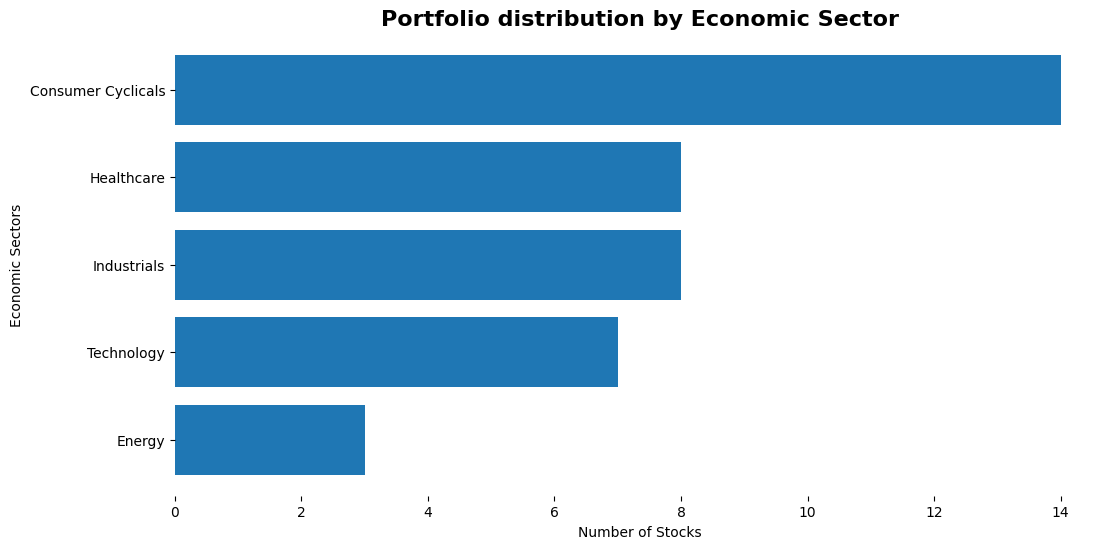

In [107]:
stocks_selected = final_qvm_df.head(40)

sector_counts = stocks_selected['TRBC Economic Sector Name'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(sector_counts.index, sector_counts.values)

ax.set_title("Portfolio distribution by Economic Sector", fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Stocks')
ax.set_ylabel('Economic Sectors')
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False) #clean axes

plt.show()

In [86]:
final_qvm_df.to_csv('12-31-2025_qvm_model_per.csv')

In [92]:
#SECTOR NEUTRALIZE

#merge all the factor scores into one df
final_qvm_sector_z_df = (
    value_score_sector_z_df[['Instrument', 'TRBC Economic Sector Name', 'value_p']]
        .merge(momentum_score_sector_z_df[['Instrument', 'momentum_p']], on='Instrument', how='outer')
        .merge(quality_score_sector_z_df[['Instrument', 'quality_p']], on='Instrument', how='outer')
)

final_qvm_sector_z_df

,Instrument,TRBC Economic Sector Name,value_p,momentum_p,quality_p
0,A.N,Healthcare,62.618432,52.708512,64.430147
1,AA.N,Basic Materials,85.099053,54.342218,28.492647
2,AAL.OQ,Industrials,82.084410,15.821152,5.698529
3,AAON.OQ,Industrials,4.306632,15.133276,70.220588
4,AAP.N,Consumer Cyclicals,2.842377,65.176268,35.294118
...,...,...,...,...,...
1159,ZD.OQ,Technology,94.573643,10.920034,67.003676
1160,ZM.OQ,Technology,91.042205,46.431642,81.801471
1161,ZS.OQ,Technology,11.283376,71.453138,NaN
1162,ZTS.N,Healthcare,71.662360,15.391230,69.944853


In [93]:
final_qvm_sector_z_df.isna().sum()

Instrument                    0
TRBC Economic Sector Name     3
value_p                       3
momentum_p                    1
quality_p                    76
dtype: int64

In [94]:
final_qvm_sector_z_df = final_qvm_sector_z_df.dropna()
final_qvm_sector_z_df.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
value_p                      0
momentum_p                   0
quality_p                    0
dtype: int64

In [103]:
# FINAL SCORE

final_qvm_sector_z_df['final_score'] = (.4 * final_qvm_sector_z_df['value_p'] +
                               .4 * final_qvm_sector_z_df['quality_p'] +
                               .2 * final_qvm_sector_z_df['momentum_p'])

#percentiles and rank
final_qvm_sector_z_df['final_score_p'] = final_qvm_sector_z_df['final_score'].rank(pct=True) * 100
final_qvm_sector_z_df['rank'] = final_qvm_sector_z_df['final_score'].rank(ascending=False)
final_qvm_sector_z_df = final_qvm_sector_z_df.sort_values(by='final_score', ascending=False)

final_qvm_sector_z_df.head(30)

,Instrument,TRBC Economic Sector Name,value_p,momentum_p,quality_p,final_score,final_score_p,rank
640,MD.N,Healthcare,93.798450,90.627687,93.106618,92.887564,100.000000,1.0
927,SIG.N,Consumer Cyclicals,98.191214,77.901978,93.841912,92.393646,99.907749,2.0
142,BKE.N,Consumer Cyclicals,95.779500,73.172829,96.783088,91.659601,99.815498,3.0
146,BLBD.OQ,Industrials,99.569337,75.408426,88.602941,90.350596,99.723247,4.0
428,GIC.N,Industrials,97.071490,64.488392,93.474265,89.115980,99.630996,5.0
76,APA.OQ,Energy,97.588286,55.631986,95.496324,88.360241,99.538745,6.0
734,NTCT.OQ,Technology,96.554694,63.370593,92.647059,88.354820,99.446494,7.0
510,IDT.N,Technology,98.880276,47.463457,97.610294,88.088919,99.354244,8.0
301,DDS.N,Consumer Cyclicals,87.252369,92.949269,86.305147,88.012860,99.261993,9.0
797,PGNY.OQ,Healthcare,83.204134,78.847807,95.955882,87.433568,99.169742,10.0


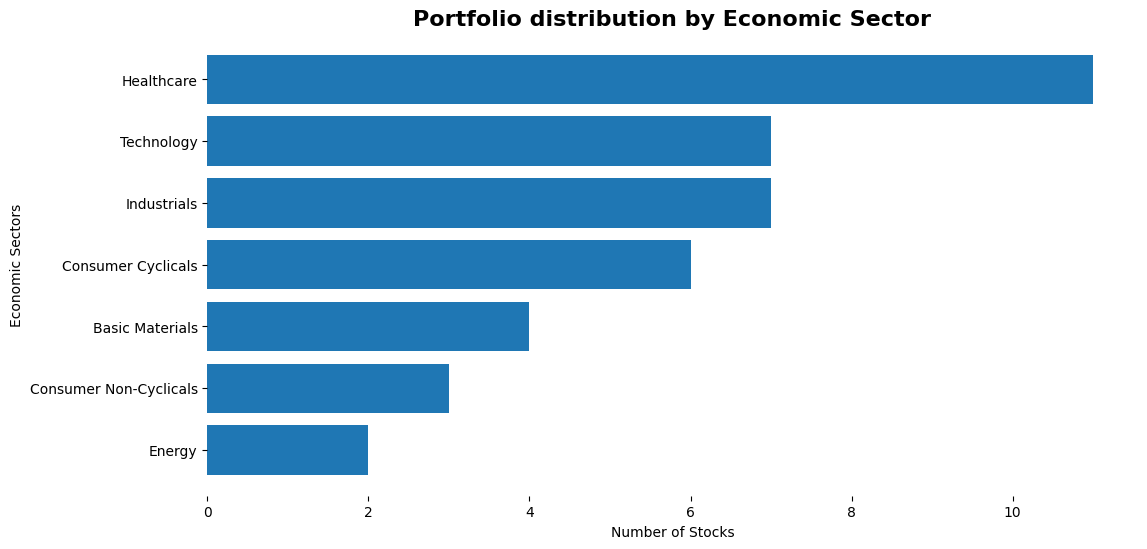

In [108]:
stocks_selected = final_qvm_sector_z_df.head(40)

sector_counts = stocks_selected['TRBC Economic Sector Name'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(sector_counts.index, sector_counts.values)

ax.set_title("Portfolio distribution by Economic Sector", fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Stocks')
ax.set_ylabel('Economic Sectors')
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False) #clean axes

plt.show()

In [96]:
final_qvm_sector_z_df.to_csv('12-31-2025_qvm_model_sector_z.csv')